<a href="https://colab.research.google.com/github/kaonashithank1022/data-analysis-basic-kadai/blob/main/text/13%E7%AB%A0_%E3%82%AF%E3%83%A9%E3%82%B9%E3%82%BF%E3%83%AA%E3%83%B3%E3%82%B0%E3%81%AE%E6%89%8B%E6%B3%95%E3%82%92%E5%AD%A6%E3%81%BC%E3%81%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
#必要なライブラリのインポート
import pandas as pd
import seaborn as sns

!pip install japanize-matplotlib -q
import japanize_matplotlib

#データセットの準備
df = pd.read_csv('/content/california_housing_cleansing.csv')
df.head()

#Unnamed: 0」列は利用しない情報なので、削除
df = df.drop(columns = ['Unnamed: 0'])
df.head()

#全18572行のデータが取り込まれているか確認
df.shape


#StandardScalerクラスのインポートとインスタンス化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#全データを変数Xに代入し、引数に指定してfitメソッドを実行
X = df.to_numpy()
scaler.fit(X)

#変換モデルを利用して、Xを標準化
X_scaled  = scaler.transform(X)
X_scaled

#clusterモジュールの KMeansクラスをインポート
from sklearn.cluster import KMeans

#KMeansクラスをインスタンス化
#クラスター数「4」を指定
#実行ごとに結果が変わることを避けたいので、random_stateを指定
model = KMeans(n_clusters=4, random_state=0)

#標準化済みデータX_scaledを用いてクラスタリングを実行
model.fit(X_scaled)

#クラスタリングの結果を表示
model.labels_

#取り込んだデータセットに、クラスター列としてラベル情報を追
df['クラスター'] = model.labels_
df.head()

#データセットのクラスタリングは完了
#クラスタリング結果に対する考察



,所得,築年数,地域人口,緯度,経度,住宅価格,部屋数/人,寝室数/人,クラスター
0,8.3252,41.0,322.0,37.88,-122.23,4.526,2.732919,0.400621,2
1,8.3014,21.0,2401.0,37.86,-122.22,3.585,2.956685,0.460641,2
2,2.0804,42.0,1206.0,37.84,-122.26,2.267,2.118574,0.551410,1
3,2.1250,50.0,697.0,37.85,-122.26,1.400,1.606887,0.406026,1
4,1.9911,50.0,990.0,37.84,-122.26,1.587,2.261616,0.459596,1


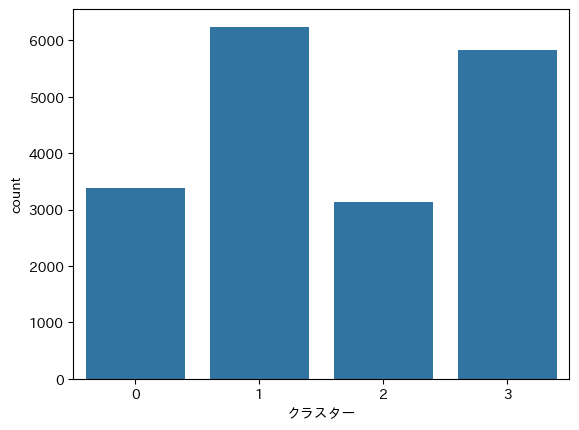

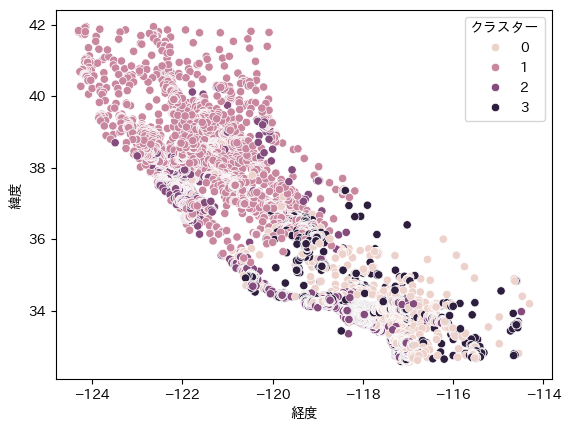

In [22]:
#seabornのcountplot関数によって、データ数を棒グラフで可視化
sns.countplot(x='クラスター', data=df)

#各クラスターの特徴をつかむために各列の平均値を確認
#Pandasのgroupbyメソッドを利用して平均値を出力
df.groupby('クラスター').mean()


#各データを緯度と経度でマッピング
#seabornのscatterplot関数を利用
import matplotlib.pyplot as plt

plt.figure()
sns.scatterplot(x='経度', y='緯度', hue='クラスター', data=df)
plt.show()


<Axes: xlabel='経度', ylabel='緯度'>

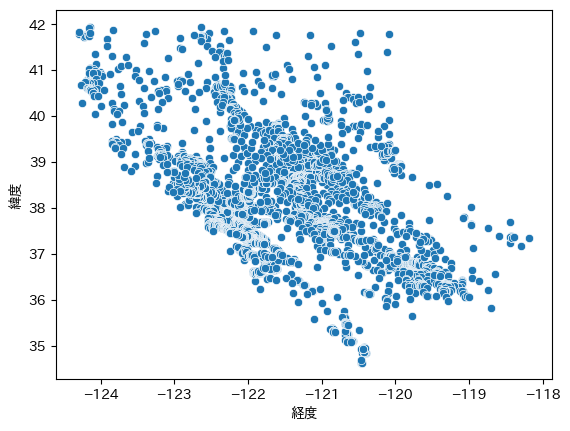

In [29]:
#富裕層のクラスターと考えられるクラスター3に絞って、緯度と経度でマッピング
df_cluster3 = df.query('クラスター == 3')
sns.scatterplot(x='経度', y='緯度', data=df_cluster3)

<Axes: xlabel='地域人口', ylabel='Count'>

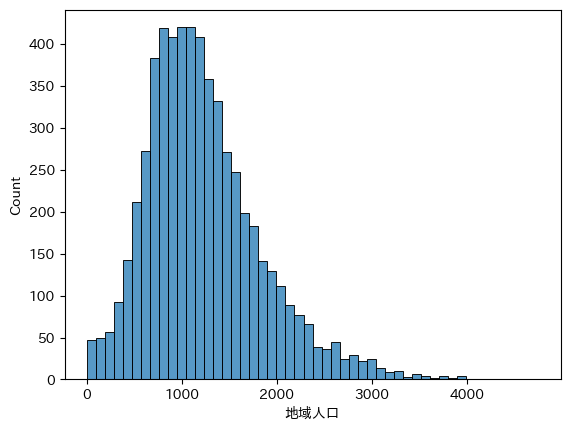

In [24]:
#クラスター3に属するデータの地域人口分布を、ヒストグラムで表示
sns.histplot(x='地域人口', data=df_cluster3, bins=50)


<Axes: xlabel='経度', ylabel='緯度'>

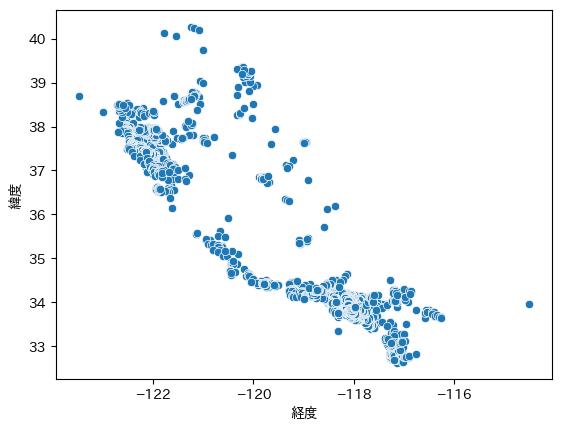

In [32]:
#クラスター2に絞って、緯度と経度でマッピング
df_cluster2 = df.query('クラスター == 2')
sns.scatterplot(x='経度', y='緯度', data=df_cluster2)

<Axes: xlabel='地域人口', ylabel='Count'>

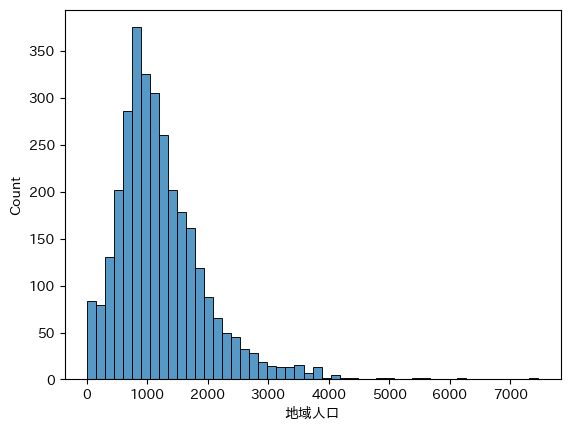

In [35]:
#クラスター2に属するデータの地域人口分布を、ヒストグラムで表示
sns.histplot(x='地域人口', data=df_cluster2, bins=50)

<Axes: xlabel='経度', ylabel='緯度'>

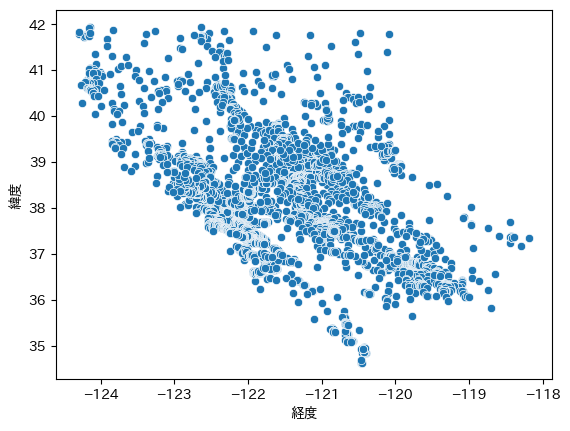

In [33]:
#クラスター1に絞って、緯度と経度でマッピング
df_cluster1 = df.query('クラスター == 1')
sns.scatterplot(x='経度', y='緯度', data=df_cluster1)

<Axes: xlabel='経度', ylabel='緯度'>

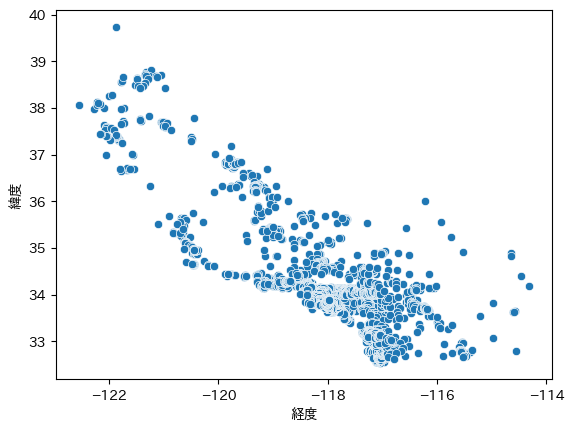

In [34]:
#クラスター0に絞って、緯度と経度でマッピング
df_cluster0 = df.query('クラスター == 0')
sns.scatterplot(x='経度', y='緯度', data=df_cluster0)

<Axes: xlabel='地域人口', ylabel='Count'>

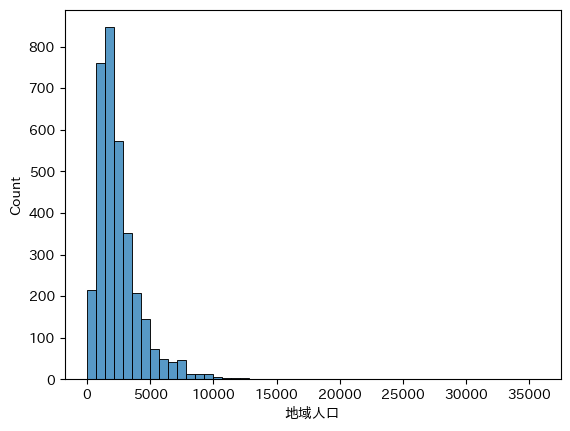

In [36]:
#クラスター0に属するデータの地域人口分布を、ヒストグラムで表示
sns.histplot(x='地域人口', data=df_cluster0, bins=50)

<Axes: xlabel='経度', ylabel='緯度'>

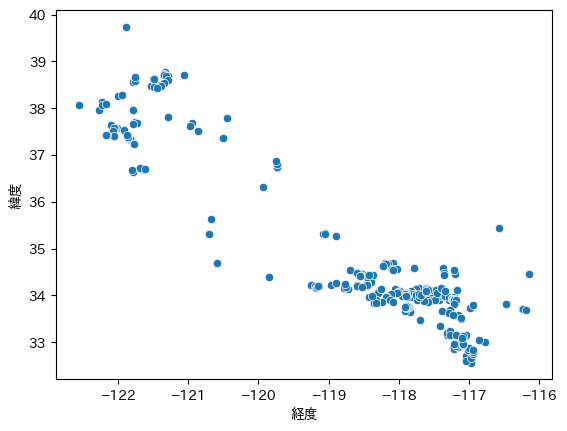

In [38]:
#人口5,000名を超えるクラスター0のデータを、緯度と経度でマッピング
sns.scatterplot(x='経度', y='緯度', data=df_cluster0.query('地域人口 > 5000'))

#地域人口が5,000名を超えるクラスター0:経度-122°緯度37.5°付近、経度-118°緯度34°のエリアに、比較的集中している,